In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_21232\3668965292.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_online_retail.csv")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print("Rows:", len(df))
print("Orders:", df["InvoiceNo"].nunique())
print("Products:", df["StockCode"].nunique())

Rows: 524878
Orders: 19962
Products: 3922


In [3]:
top_products = (
    df.groupby("StockCode")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(20)
)

print(top_products)

StockCode
85123A    2198
85099B    2089
22423     1988
47566     1685
20725     1565
84879     1455
22197     1392
22720     1385
21212     1320
22383     1285
20727     1273
22457     1249
23203     1231
22386     1218
22469     1201
21931     1184
22411     1175
22961     1162
22086     1160
22382     1157
Name: InvoiceNo, dtype: int64


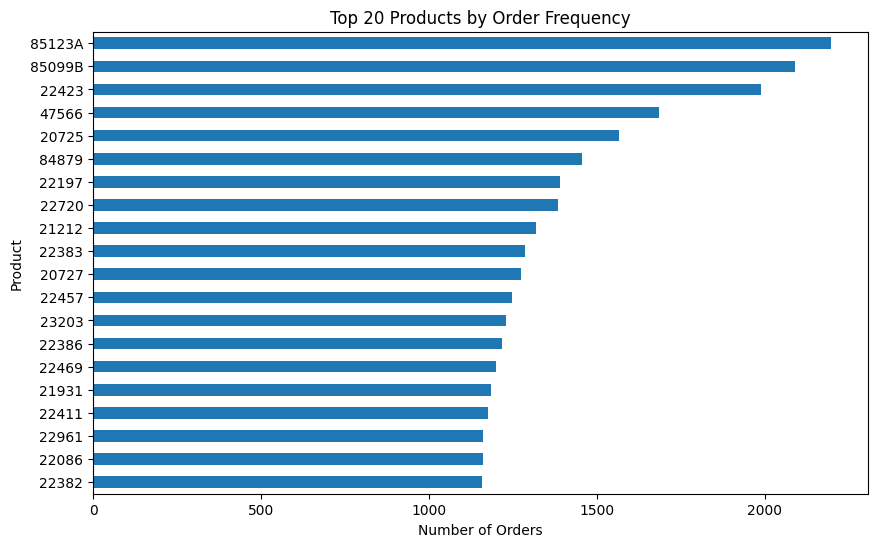

In [4]:
top_products.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Top 20 Products by Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.show()

In [5]:
top_quantity = (
    df.groupby("StockCode")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print(top_quantity)

StockCode
23843     80995
23166     78033
22197     56898
84077     54951
85099B    48371
85123A    37641
21212     36396
84879     36362
23084     30739
22492     26633
22616     26119
21977     24820
22178     24275
15036     23826
17003     23020
21915     21903
22386     21448
23203     20485
20725     19432
22086     19329
Name: Quantity, dtype: int64


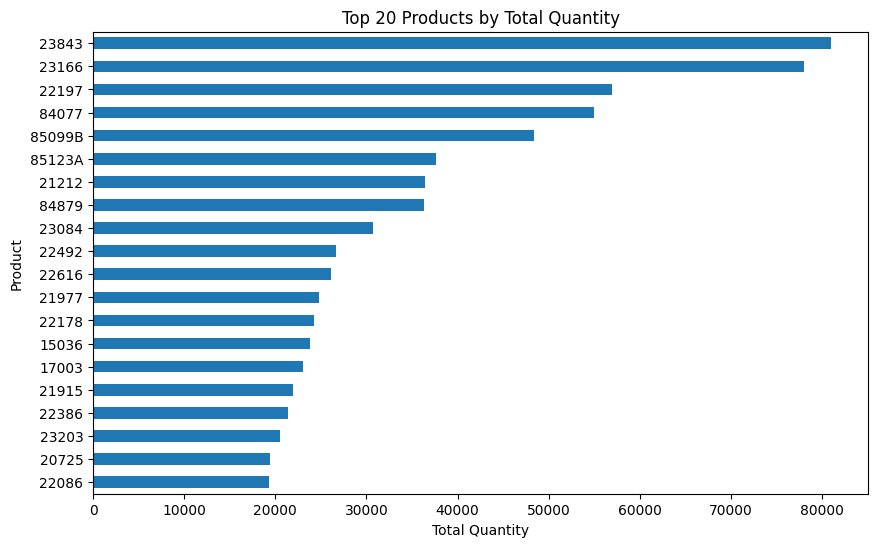

In [6]:
top_quantity.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 20 Products by Total Quantity")
plt.xlabel("Total Quantity")
plt.ylabel("Product")
plt.show()

In [7]:
product_summary = df.groupby("StockCode").agg(
    order_frequency=("InvoiceNo", "nunique"),
    total_quantity=("Quantity", "sum")
)

product_summary.head()

,order_frequency,total_quantity
StockCode,,
10002,71,860
10080,22,303
10120,29,192
10123C,3,5
10124A,5,16


In [8]:
monthly_orders = (
    df.set_index("InvoiceDate")
      .resample("ME")["InvoiceNo"]
      .nunique()
)

monthly_orders

InvoiceDate
2010-12-31    1559
2011-01-31    1086
2011-02-28    1100
2011-03-31    1454
2011-04-30    1246
2011-05-31    1681
2011-06-30    1533
2011-07-31    1476
2011-08-31    1361
2011-09-30    1838
2011-10-31    2040
2011-11-30    2769
2011-12-31     819
Freq: ME, Name: InvoiceNo, dtype: int64

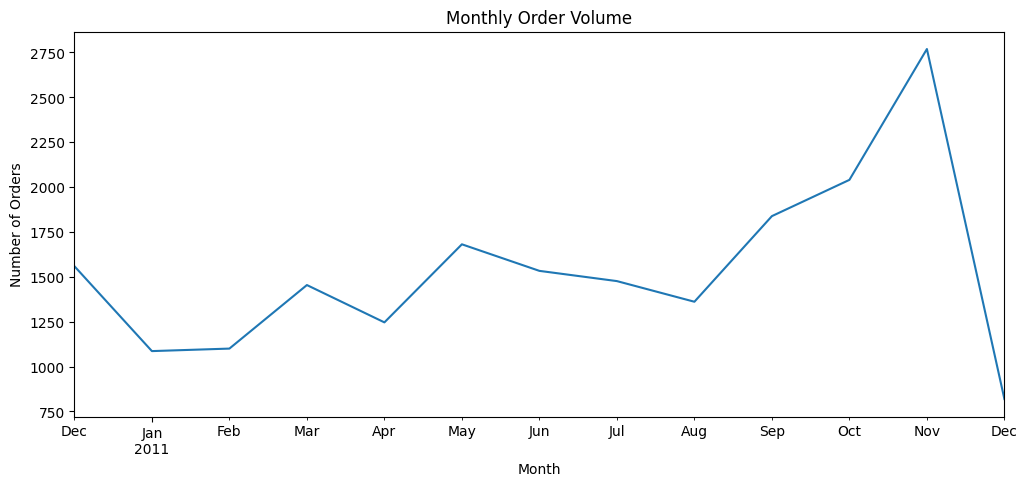

In [9]:
monthly_orders.plot(figsize=(12,5))

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

In [10]:
products_per_order = (
    df.groupby("InvoiceNo")["StockCode"]
      .nunique()
)

products_per_order.describe()

count    19962.000000
mean        26.029606
std         46.978946
min          1.000000
25%          6.000000
50%         15.000000
75%         29.000000
max       1110.000000
Name: StockCode, dtype: float64

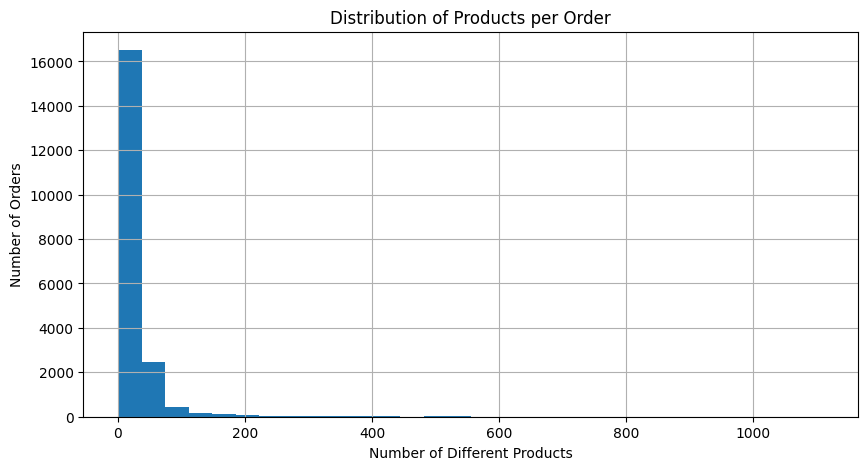

In [11]:
products_per_order.hist(bins=30, figsize=(10,5))

plt.title("Distribution of Products per Order")
plt.xlabel("Number of Different Products")
plt.ylabel("Number of Orders")
plt.show()

In [12]:
product_summary["order_frequency"].describe()

count    3922.000000
mean      132.484192
std       193.890513
min         1.000000
25%        16.000000
50%        65.000000
75%       165.000000
max      2198.000000
Name: order_frequency, dtype: float64

In [13]:
country_orders = (
    df.groupby("Country")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

print(country_orders)

Country
United Kingdom    18020
Germany             458
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64


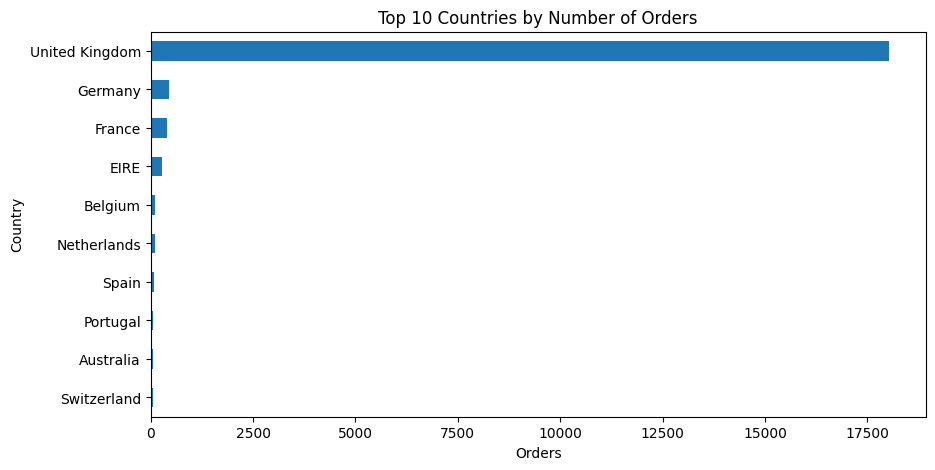

In [14]:
country_orders.sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Orders")
plt.ylabel("Country")
plt.show()